In [1]:
import pandas as pd
import numpy as np

In [4]:

train = pd.read_csv("data/kaggle_b2_fraud_train_v3.csv")
test  = pd.read_csv("data/kaggle_b2_fraud_test_v3.csv")



In [5]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)


Train shape: (160000, 56)
Test shape: (40000, 55)


In [6]:
train.head()


,customer_id,account_id,age,tenure_months,annual_income_eur,credit_score,num_transactions_30d,avg_amount_30d_eur,max_amount_30d_eur,days_since_last_login,...,internal_signal_5,internal_signal_6,internal_signal_7,internal_signal_8,terms_accepted_flag,partner_risk_indicator,manual_review_result,post_event_status_code,chargeback_resolution_time_days,legacy_partner_score
0,CUST_6O9Q8D4I36,ACC_TXXXTNEUVKFY,34,108,38635.01,544.0,20,60.92,80.16,4.9,...,0.39006,0.10963,0.55097,-0.56104,1,NaN,approve,0,7.9,NaN
1,CUST_FGUGTW230C,ACC_70VD7A4FFWCW,48,2,19912.97,703.0,21,112.11,571.12,0.3,...,0.03265,-0.40256,0.36218,0.86583,1,NaN,approve,0,5.5,NaN
2,CUST_8ZI3LCBZ0W,ACC_AF53381QSC0L,27,0,20326.87,720.0,25,73.61,492.57,4.6,...,-0.15637,0.57818,0.28902,-2.19864,1,NaN,approve,0,7.2,NaN
3,CUST_5MP3AR41CJ,ACC_U7WZGJ486LIV,45,49,38452.47,703.0,17,47.53,204.18,25.3,...,-1.02145,0.63908,-0.89190,-0.81592,1,NaN,approve,0,4.4,NaN
4,CUST_GNPL83JB0J,ACC_XW7DS3ED5J4Y,37,46,NaN,594.0,13,99.95,734.09,12.8,...,-0.65771,0.08020,0.17606,0.86739,1,NaN,approve,0,4.9,NaN


In [7]:
train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160000 entries, 0 to 159999
Data columns (total 56 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   customer_id                      160000 non-null  object 
 1   account_id                       160000 non-null  object 
 2   age                              160000 non-null  int64  
 3   tenure_months                    160000 non-null  int64  
 4   annual_income_eur                148814 non-null  float64
 5   credit_score                     152048 non-null  float64
 6   num_transactions_30d             160000 non-null  int64  
 7   avg_amount_30d_eur               150453 non-null  float64
 8   max_amount_30d_eur               152077 non-null  float64
 9   days_since_last_login            160000 non-null  float64
 10  support_tickets_90d              160000 non-null  int64  
 11  chargebacks_12m                  160000 non-null  int64  
 12  fa

In [8]:
num_cols = train.select_dtypes(include="number").columns
cat_cols = train.select_dtypes(include="object").columns

print("Numerical columns:", len(num_cols))
print("Categorical columns:", len(cat_cols))


Numerical columns: 36
Categorical columns: 20


In [9]:
missing = train.isnull().mean().sort_values(ascending=False)

missing_df = pd.DataFrame({
    "Missing %": missing,
    "Missing Count": train.isnull().sum()
})

missing_df[missing_df["Missing %"] > 0]


,Missing %,Missing Count
annual_income_eur,0.069913,11186
avg_amount_30d_eur,0.059669,9547
credit_score,0.049700,7952
customer_note,0.030013,4802
device_trust_z,0.039900,6384
ip_risk_z,0.029794,4767
last_ticket_subject,0.029500,4720
legacy_partner_score,0.960850,153736
max_amount_30d_eur,0.049519,7923
merchant_category,0.019613,3138


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns


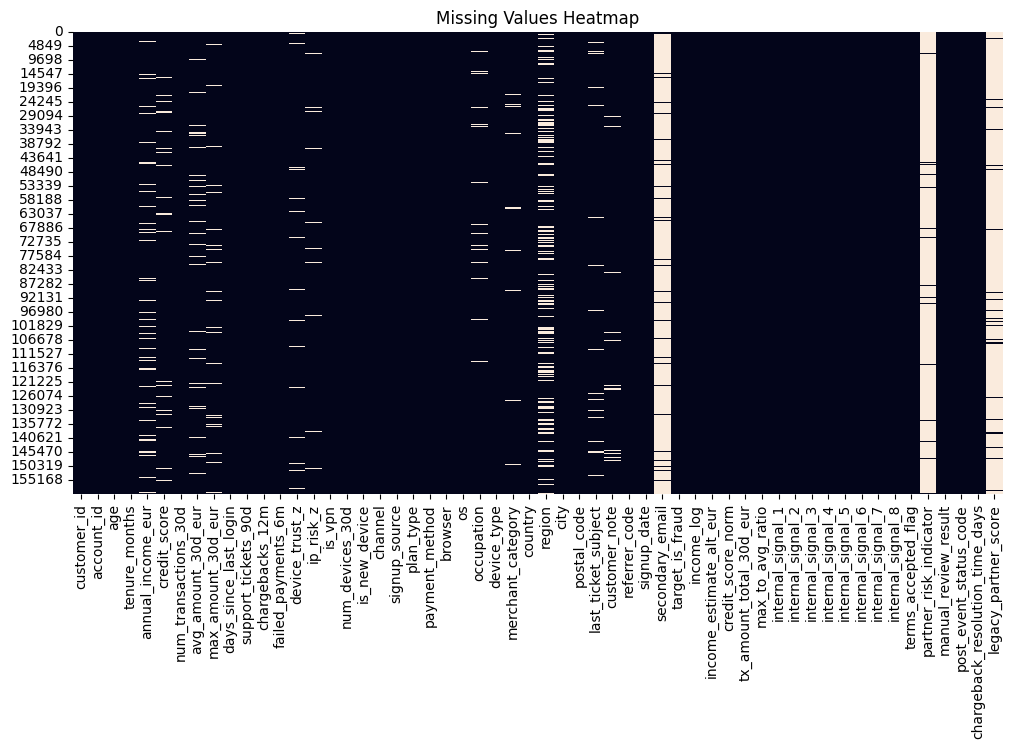

In [12]:
plt.figure(figsize=(12,6))
sns.heatmap(train.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()


In [13]:
train[num_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
age,160000.0,38.239075,11.751027,-14.000000,30.000000,38.000000,46.000000,1.590000e+02
tenure_months,160000.0,17.898356,17.781320,-23.000000,5.000000,12.000000,25.000000,1.200000e+02
annual_income_eur,148814.0,37610.707341,26937.658309,-19941.709231,22048.442500,31943.140000,46450.790000,1.355012e+06
credit_score,152048.0,670.067327,59.985184,380.000000,630.000000,670.000000,710.000000,8.500000e+02
num_transactions_30d,160000.0,22.901775,34.776594,5.000000,19.000000,22.000000,25.000000,1.923000e+03
avg_amount_30d_eur,150453.0,61.626094,41.795545,-49.675409,30.970000,52.540000,82.370000,4.171000e+02
max_amount_30d_eur,152077.0,298.683078,256.039318,0.610000,117.380000,224.730000,402.170000,2.994200e+03
days_since_last_login,160000.0,12.019874,12.033636,0.000000,3.500000,8.300000,16.700000,1.846000e+02
support_tickets_90d,160000.0,0.797850,0.894715,0.000000,0.000000,1.000000,1.000000,7.000000e+00
chargebacks_12m,160000.0,0.049931,0.223217,0.000000,0.000000,0.000000,0.000000,3.000000e+00


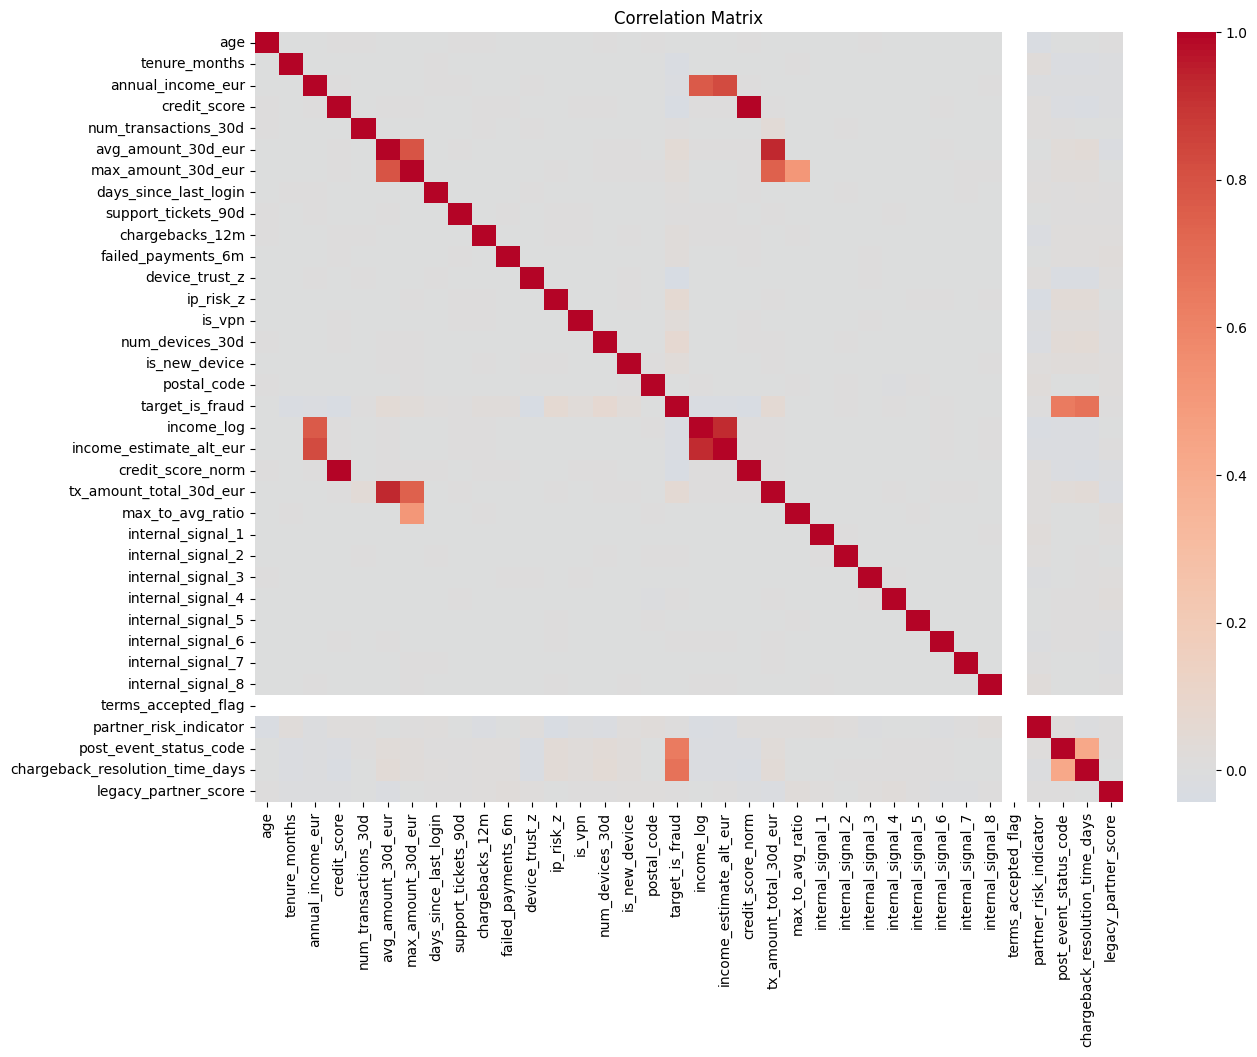

In [14]:
#Correlation
plt.figure(figsize=(14,10))
sns.heatmap(train[num_cols].corr(), cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()


In [ ]:
# Identification de correlations fortes
corr_matrix = train[num_cols].corr().abs()

high_corr = (
    corr_matrix
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)

high_corr[high_corr > 0.8]


credit_score        credit_score_norm          1.000000
avg_amount_30d_eur  tx_amount_total_30d_eur    0.933817
income_log          income_estimate_alt_eur    0.925534
annual_income_eur   income_estimate_alt_eur    0.822232
dtype: float64

In [16]:
#Analyse comportement transactionnel
train[[
    "num_transactions_30d",
    "avg_amount_30d_eur",
    "max_amount_30d_eur",
    "tx_amount_total_30d_eur",
    "max_to_avg_ratio"
]].describe()


,num_transactions_30d,avg_amount_30d_eur,max_amount_30d_eur,tx_amount_total_30d_eur,max_to_avg_ratio
count,160000.000000,150453.000000,152077.000000,160000.000000,160000.000000
mean,22.901775,61.626094,298.683078,1355.963553,4.849859
std,34.776594,41.795545,256.039318,982.603772,2.108470
min,5.000000,-49.675409,0.610000,3.780000,1.198900
25%,19.000000,30.970000,117.380000,648.480000,3.018975
50%,22.000000,52.540000,224.730000,1123.720000,4.851400
75%,25.000000,82.370000,402.170000,1805.547500,6.679400
max,1923.000000,417.100000,2994.200000,10998.830000,8.500000


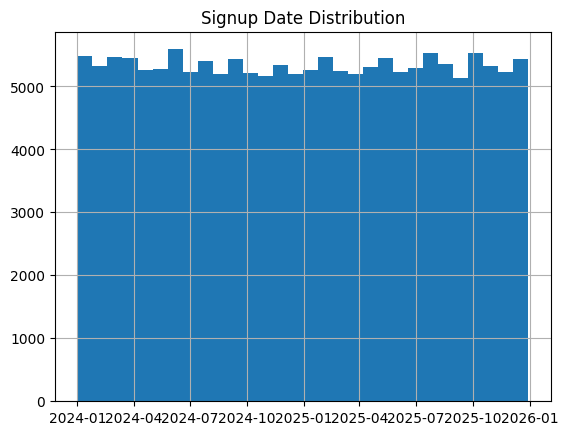

In [17]:
#Analyse temporelle
train["signup_date"] = pd.to_datetime(train["signup_date"])

train["signup_date"].hist(bins=30)
plt.title("Signup Date Distribution")
plt.show()


### PRE-PROCESSING